In [1]:
include("1body_NM.jl")
using LinearAlgebra
using PolyChaos
using QuadGK
using Plots
using ProgressMeter
using Kronecker
using JLD2
using SparseArrays
using .NM_measures_1body

In [ ]:
P = set_P()
mu = 0.0 #must be zero for this calculation
beta = 20.0
gamma = 0.01
N = 50
T = 50.0

P.spec_fun = "ellipse"
P.T = T
P.N_L = N
P.N_R = N
P.v = 1000
P.Γ_L = gamma
P.Γ_R = gamma
P.β_L = beta
P.β_R = beta
P.μ_L = mu
P.μ_R = mu

base_TD, _, _ = calculate_SBcorr_effect(P)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:32


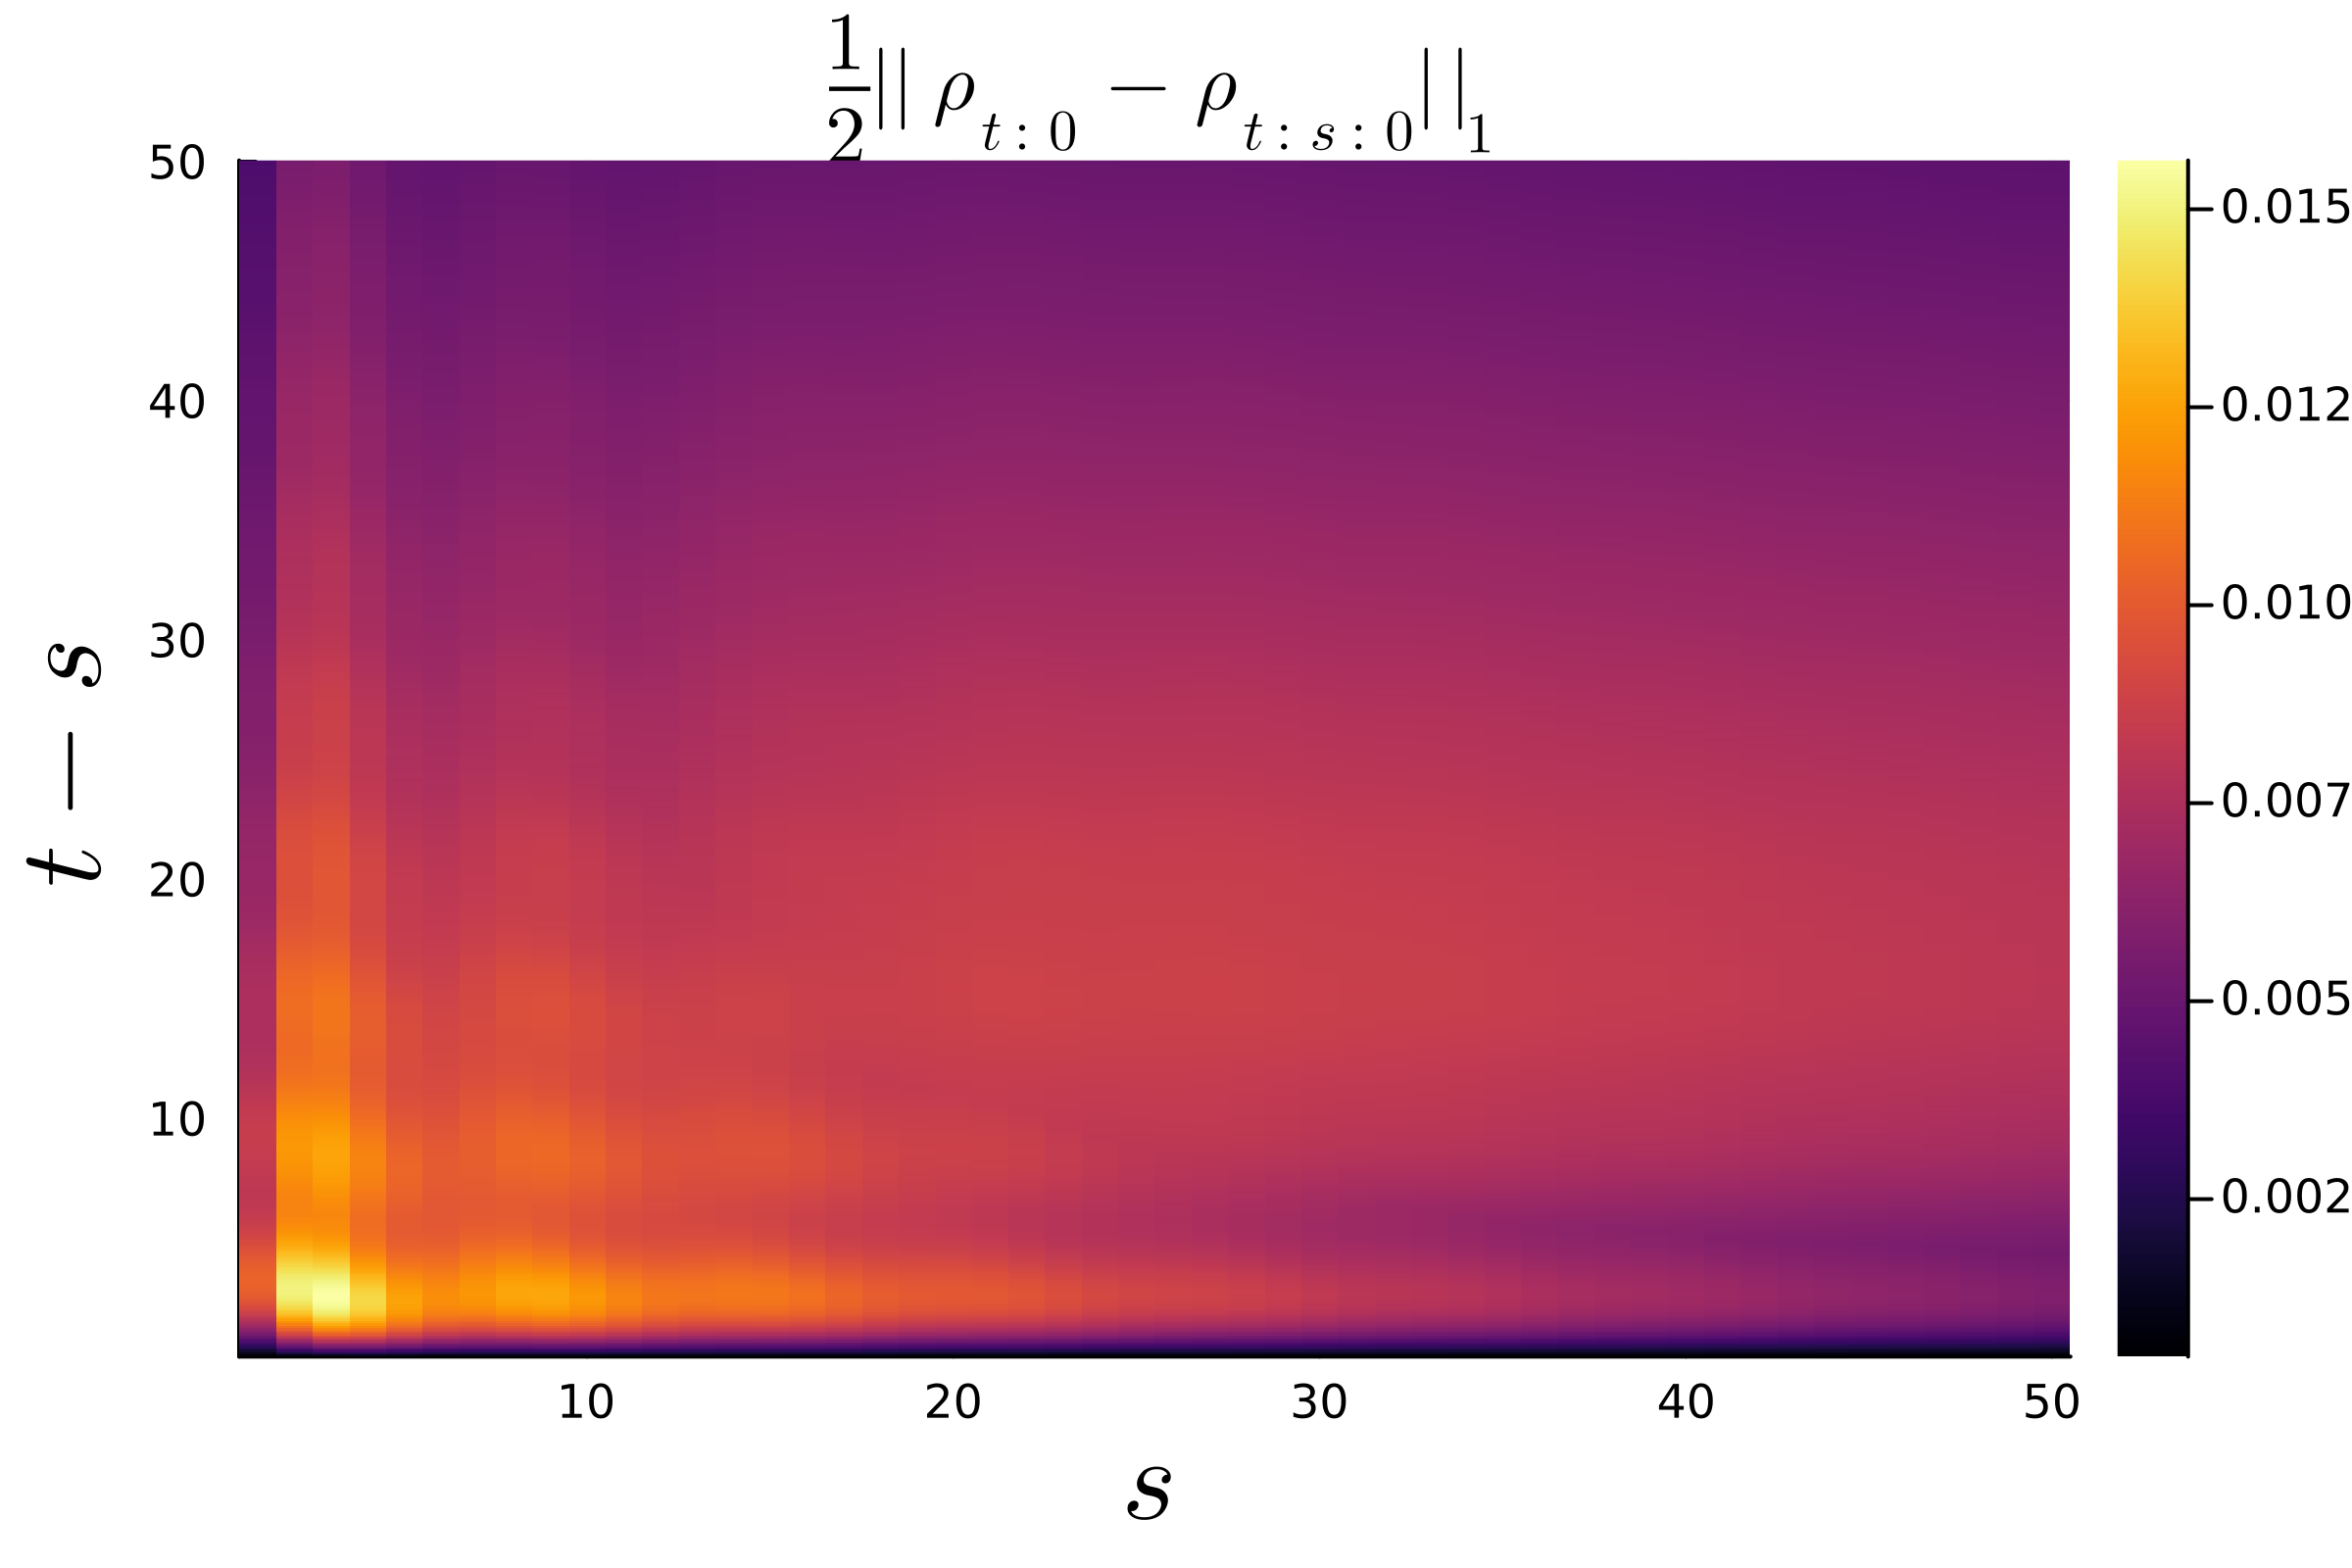

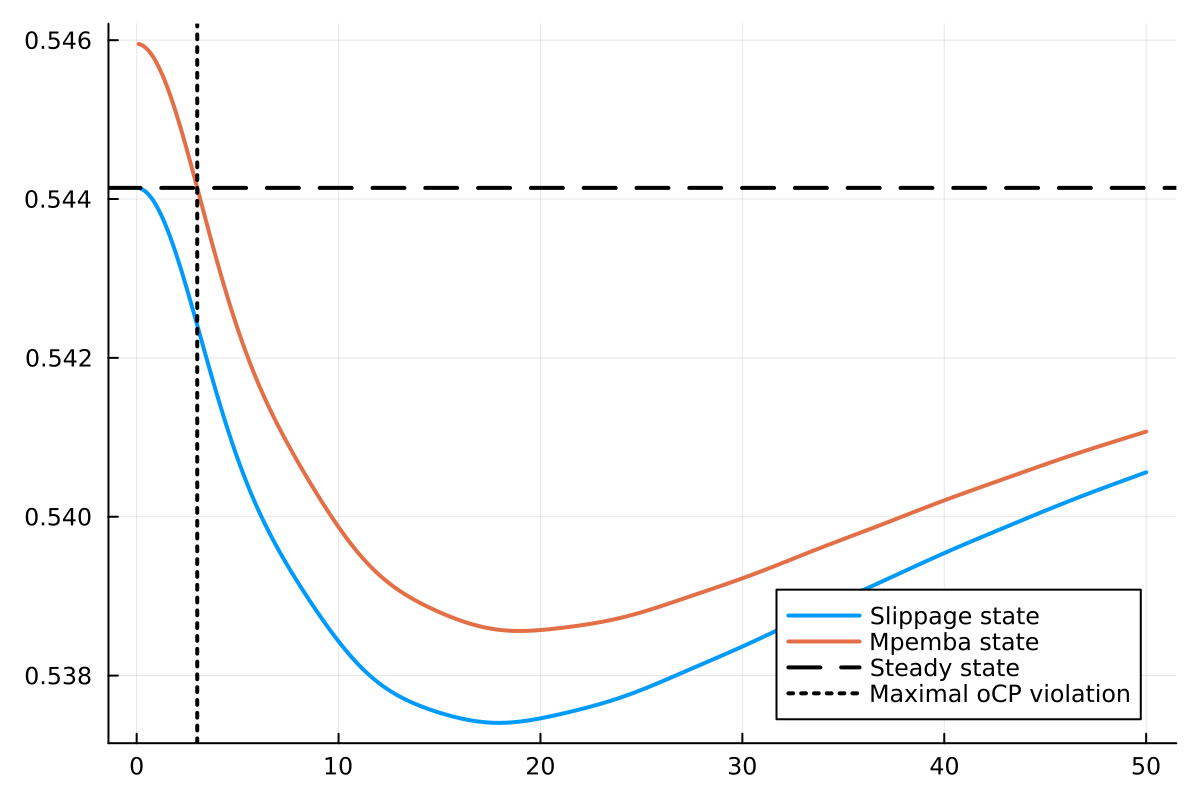

Mpemba state is 0.5459546095517402, Steady state is 0.5441401393856568.
Difference is 0.0018144701660834928


In [ ]:
mu = 0.01

tracedist, times, s_times = calculate_SBcorr_effect(P)
tracedist = tracedist .- base_TD
p = heatmap(s_times, times, tracedist, xlabel="\$s\$", ylabel="\$t-s\$",
            title="\$\\frac{1}{2}||\\rho_{t:0} - \\rho_{t:s:0}||_1\$", dpi=400,
            guidefontsize=20)
display(p)

SB_effect = sum(tracedist, dims=1)
_, idx = Tuple(10 * argmax(SB_effect)) 
mem_time = times[idx]

pf, pinf = calculate_Mpemba(P, mem_time)
println("Difference is $(pf - pinf)")
qS = 2*N + 2 

J_L = spectral_function(P, "L")
J_R = spectral_function(P, "R")

H = H_tot(J_L, J_R, P)
C0_e = prepare_corrs(P)
C0_e[qS,qS] = pf
C0_f = prepare_corrs(P)
C0_f[qS,qS] = pinf
Cs_e = evolve_corrs(C0_e, H, P, T)[2:end]
Cs_f = evolve_corrs(C0_f, H, P, T)[2:end]

rho1 = [real(C[qS,qS]) for C in Cs_f]
rho2 = [real(C[qS,qS]) for C in Cs_e]

p = plot(times, rho1, lw=2, label="Slippage state", dpi=200)
plot!(p, times, rho2, lw=2, label="Mpemba state")
hline!(p, [pinf], lw=2, c=:black, linestyle=:dash, label="Steady state")
vline!(p, [mem_time], lw=2, c=:black, linestyle=:dot, label="Maximal oCP violation")
display(p)


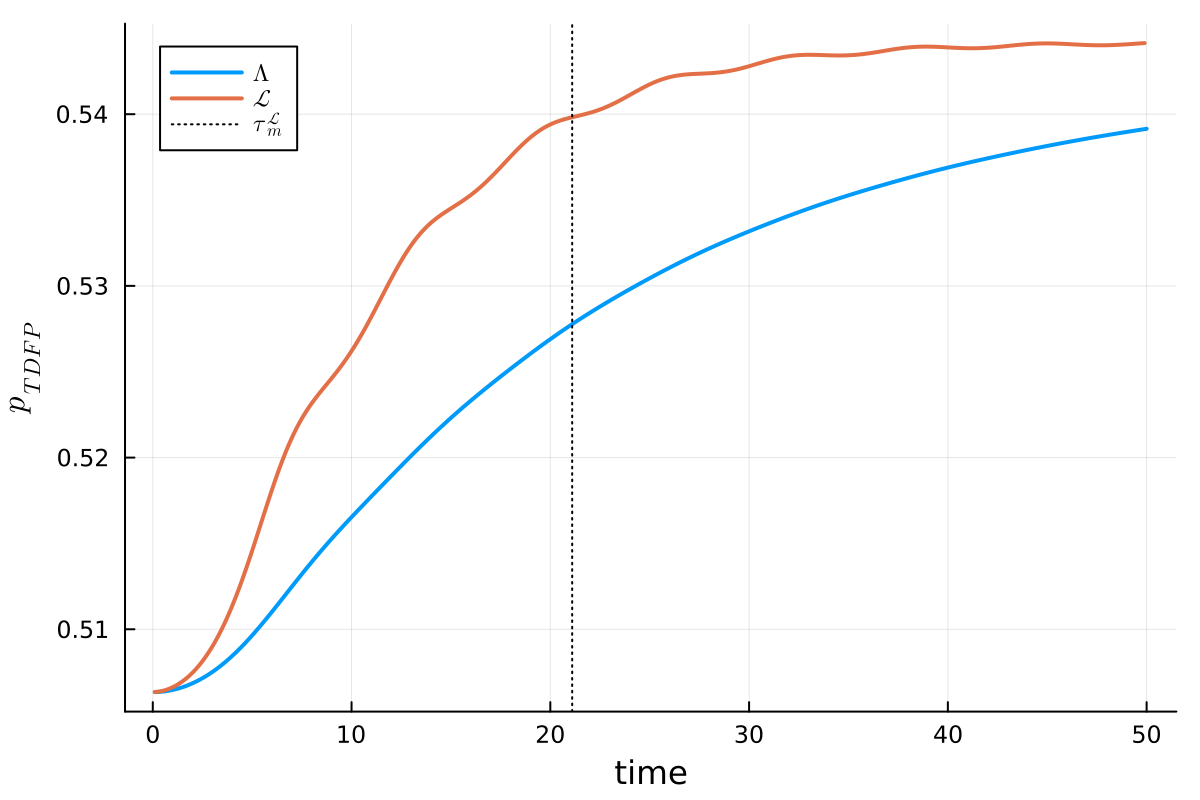

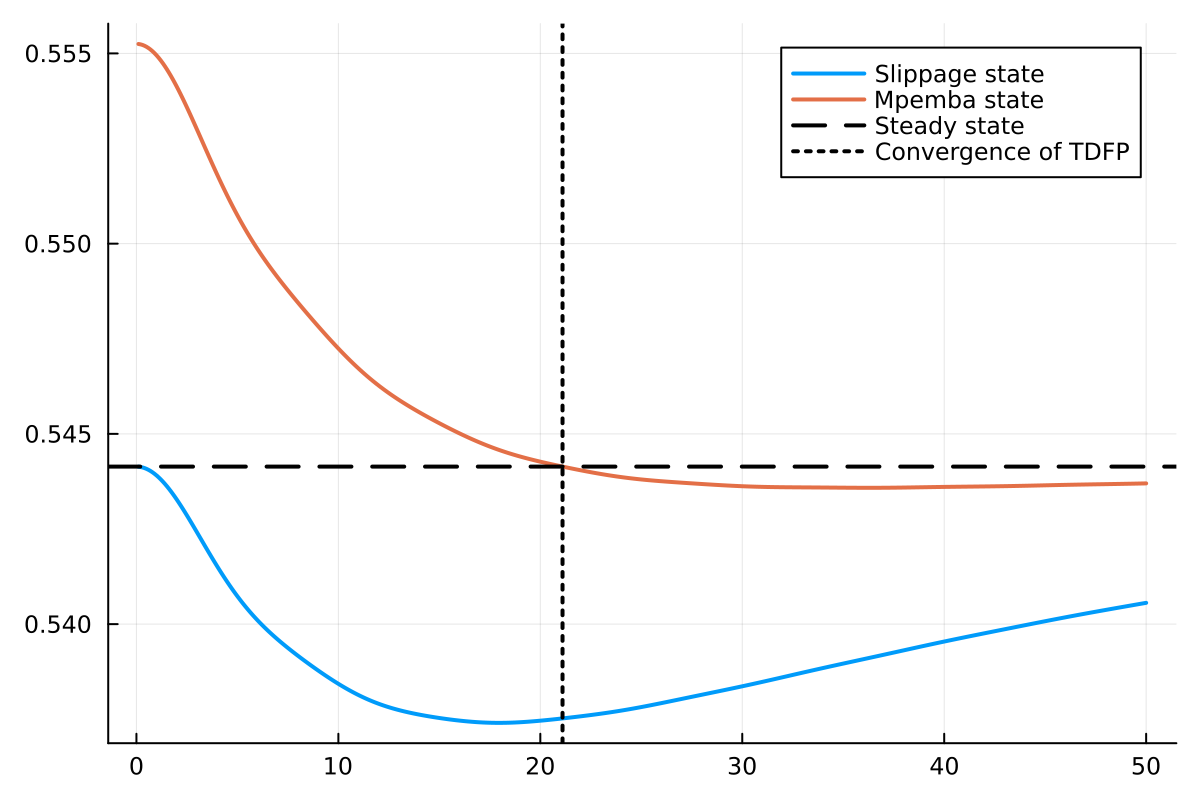

Mpemba state is 0.5552512122245008, Steady state is 0.5441401393856568.
Difference is 0.01111107283884405


In [3]:
converge_time, _, _ = calculate_TDFP(P, plotting=true)

pf, pinf = calculate_Mpemba(P, converge_time)
println("Difference is $(pf - pinf)")
qS = 2*N + 2 

J_L = spectral_function(P, "L")
J_R = spectral_function(P, "R")

H = H_tot(J_L, J_R, P)
C0_e = prepare_corrs(P)
C0_e[qS,qS] = pf
C0_f = prepare_corrs(P)
C0_f[qS,qS] = pinf
Cs_e = evolve_corrs(C0_e, H, P, T)[2:end]
Cs_f = evolve_corrs(C0_f, H, P, T)[2:end]

rho1 = [real(C[qS,qS]) for C in Cs_f]
rho2 = [real(C[qS,qS]) for C in Cs_e]

p = plot(times, rho1, lw=2, label="Slippage state", dpi=200)
plot!(p, times, rho2, lw=2, label="Mpemba state")
hline!(p, [pinf], lw=2, c=:black, linestyle=:dash, label="Steady state")
vline!(p, [converge_time], lw=2, c=:black, linestyle=:dot, label="Convergence of TDFP")
display(p)